<a href="https://colab.research.google.com/github/ajaykumar080286/MachineLearning/blob/main/55_adaboost_hyperparameter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.ensemble import AdaBoostClassifier
from sklearn.datasets import make_circles
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

In [12]:
np.random.seed(42)
X, y = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)


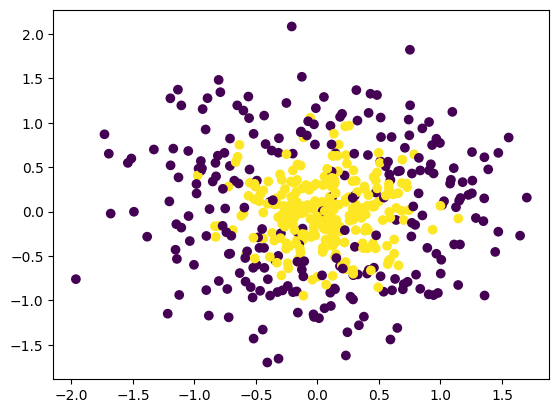

In [13]:
plt.scatter(X[:,0],X[:,1],c=y)

In [14]:
ada=AdaBoostClassifier()

In [18]:
np.mean(cross_val_score(ada, X, y, cv=10, scoring="accuracy"))

np.float64(0.812)

In [19]:
ada.fit(X,y)

AdaBoostClassifier()

In [24]:
def plot_decision_boundary(clf):
    plt.figure(figsize=(12, 8))
    x_range = np.linspace(X.min(), X.max(), 100)
    xx1, xx2 = np.meshgrid(x_range, x_range)
    y_hat = clf.predict(np.c_[xx1.ravel(), xx2.ravel()])
    y_hat = y_hat.reshape(xx1.shape)
    plt.contourf(xx1, xx2, y_hat, alpha=0.2)
    plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)
    plt.title("Adaboost Classifier")
    plt.show()



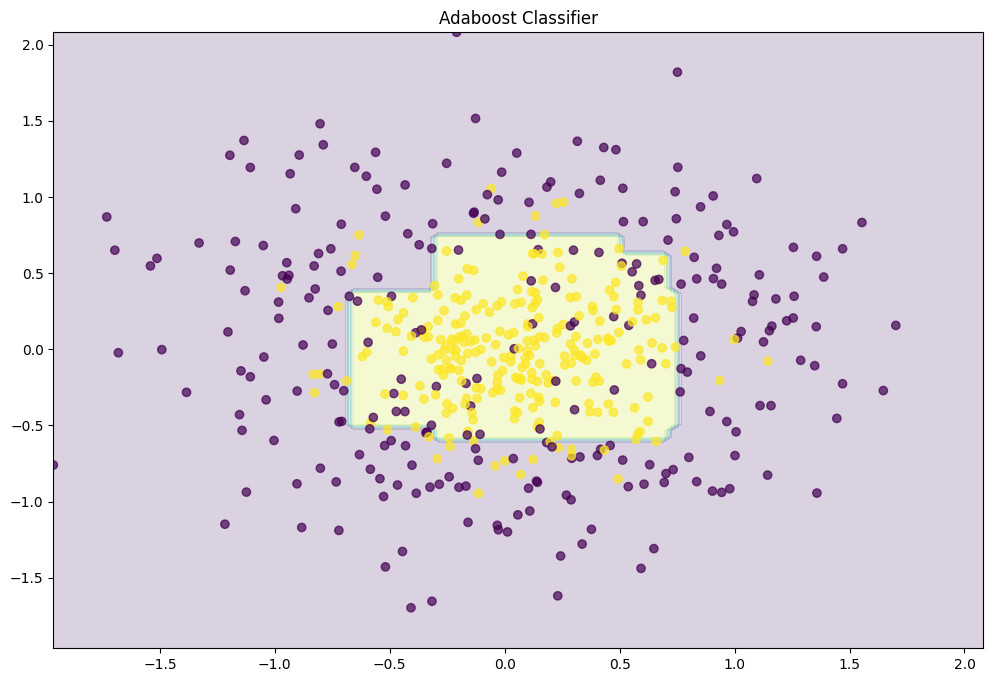

In [25]:
plot_decision_boundary(ada)

In [26]:
ada1=AdaBoostClassifier(n_estimators=100, learning_rate=0.1)

In [27]:
ada1.fit(X,y)

AdaBoostClassifier(learning_rate=0.1, n_estimators=100)

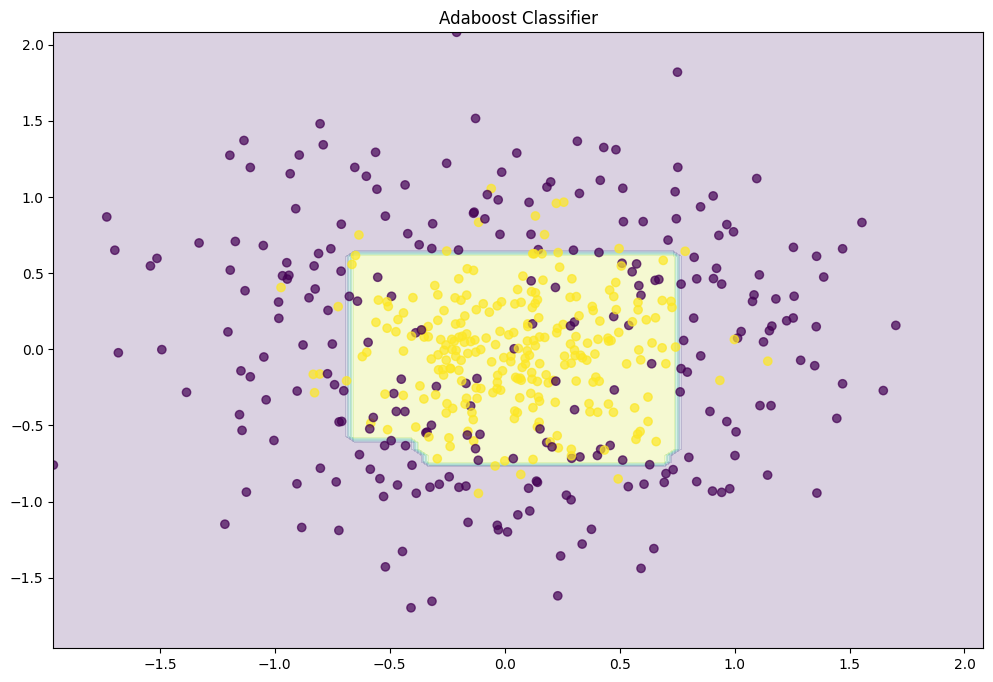

In [28]:
plot_decision_boundary(ada1)

In [36]:
param={
    "n_estimators":[1,2,3],
    "learning_rate":[0.0001, 0.001, 0.01, 0.1, 1.0],
    "algorithm":['SAMME']

}

In [37]:
grid=GridSearchCV(AdaBoostClassifier(),param_grid=param,cv=10,scoring="accuracy")

In [38]:
grid.fit(X, y)

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 

GridSearchCV(cv=10, estimator=AdaBoostClassifier(),
             param_grid={'algorithm': ['SAMME'],
                         'learning_rate': [0.0001, 0.001, 0.01, 0.1, 1.0],
                         'n_estimators': [1, 2, 3]},
             scoring='accuracy')

In [39]:
grid.best_params_

{'algorithm': 'SAMME', 'learning_rate': 1.0, 'n_estimators': 3}

In [40]:
grid.best_score_

np.float64(0.6639999999999999)